## Implementation

### Loading Required Libraries
Import all necessary libraries for data processing, machine learning, and visualization.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, matthews_corrcoef
import matplotlib.pyplot as plt
import time

### Main Processing Function
This function handles the complete pipeline for each dataset: loading data, preprocessing with standardization, training baseline models, applying PCA, training models with reduced features, and computing performance metrics.

In [ ]:
def process_dataset(csv_path, label_col=None):
    with open(csv_path, 'r') as f:
        first_line = f.readline()
    delimiter = ';' if first_line.count(';') > first_line.count(',') else ','

    df = pd.read_csv(csv_path, sep=delimiter)

    if not pd.to_numeric(df.iloc[:, 0], errors='coerce').notna().mean() > 0.8:
        df = df.set_index(df.columns[0])

    if label_col is None:
        if 'label' in df.columns:
            label_col = 'label'
        elif 'type' in df.columns:
            label_col = 'type'
        elif 'class' in df.columns:
            label_col = 'class'
        else:
            label_col = df.columns[-1]

    X = df.drop(label_col, axis=1)
    y = df[label_col]

    X = X.apply(pd.to_numeric, errors='coerce').fillna(0)
    y_numeric = pd.to_numeric(y, errors='coerce')

    if y_numeric.isna().any():
        y_classes = y.unique()
        y_map = {cls: idx for idx, cls in enumerate(y_classes)}
        y = y.map(y_map)
    else:
        y = y_numeric

    y = y.fillna(0)

    mask = X.notna().all(axis=1) & y.notna()
    X = X[mask]
    y = y[mask]

    if y.nunique() > 2:
        y = (y != y.unique()[0]).astype(int)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    try:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42, stratify=y
        )
    except:
        X_train, X_test, y_train, y_test = train_test_split(
            X_scaled, y, test_size=0.2, random_state=42
        )

    models = {
        'SVC': SVC(),
        'RandomForest': RandomForestClassifier(random_state=42),
        'MLP': MLPClassifier(max_iter=500, random_state=42)
    }

    results_baseline = {}
    for name, model in models.items():
        start = time.time()
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        end = time.time()

        results_baseline[name] = {
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred, average='binary', zero_division=0),
            'recall': recall_score(y_test, pred, average='binary', zero_division=0),
            'mcc': matthews_corrcoef(y_test, pred),
            'time': end - start
        }

        if name == 'MLP':
            plt.figure(figsize=(8,4))
            plt.plot(model.loss_curve_)
            plt.title(f'MLP Loss - {csv_path}')
            plt.xlabel('Epoch')
            plt.ylabel('Loss')
            plt.show()

    n_pca = min(50, X_train.shape[0], X_train.shape[1])
    pca = PCA(n_components=n_pca)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)

    results_ablation = {}
    for name, model in models.items():
        start = time.time()
        model.fit(X_train_pca, y_train)
        pred = model.predict(X_test_pca)
        end = time.time()

        results_ablation[name] = {
            'accuracy': accuracy_score(y_test, pred),
            'precision': precision_score(y_test, pred, average='binary', zero_division=0),
            'recall': recall_score(y_test, pred, average='binary', zero_division=0),
            'mcc': matthews_corrcoef(y_test, pred),
            'time': end - start
        }

    return results_baseline, results_ablation

### Dataset 1: CuMiDa Microarray Data
Processing the first dataset containing microarray gene expression data with normal vs. malignant tumor classification.

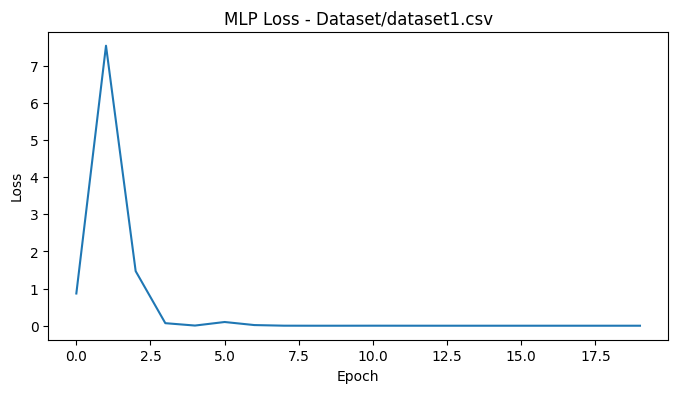

Dataset 1 - Baseline Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.484830379486084}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.5580790042877197}, 'MLP': {'accuracy': 0.9032258064516129, 'precision': 1.0, 'recall': 0.9, 'mcc': np.float64(0.4743416490252569), 'time': 9.34199571609497}}

Dataset 1 - PCA Ablation Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.0034334659576416016}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.20141363143920898}, 'MLP': {'accuracy': 0.967741935483871, 'precision': 1.0, 'recall': 0.9666666666666667, 'mcc': np.float64(0.695221787153807), 'time': 0.03131818771362305}}


In [ ]:
baseline1, ablation1 = process_dataset('Dataset/dataset1.csv')
print("Dataset 1 - Baseline Results:")
print(baseline1)
print("\nDataset 1 - PCA Ablation Results:")
print(ablation1)

### Dataset 2: GSE280902 Chemotherapy Response
RNA-Seq data classifying patient response to chemotherapy treatment. This is a smaller dataset (51 samples) which may result in lower accuracy.

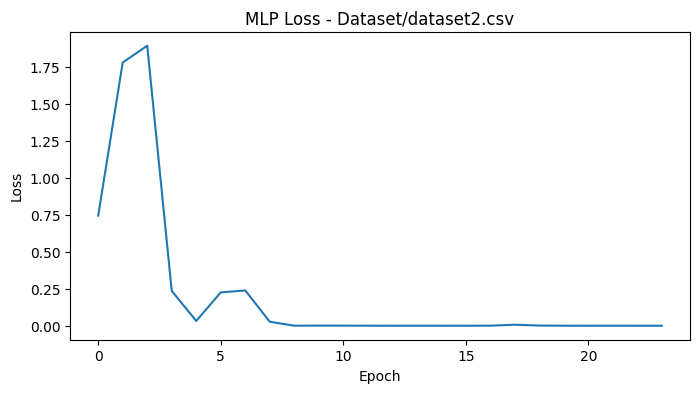

Dataset 2 - Baseline Results:
{'SVC': {'accuracy': 0.7272727272727273, 'precision': 0.6666666666666666, 'recall': 0.8, 'mcc': np.float64(0.4666666666666667), 'time': 0.04578733444213867}, 'RandomForest': {'accuracy': 0.7272727272727273, 'precision': 0.625, 'recall': 1.0, 'mcc': np.float64(0.5590169943749475), 'time': 0.4371814727783203}, 'MLP': {'accuracy': 0.5454545454545454, 'precision': 0.5, 'recall': 0.2, 'mcc': np.float64(0.04303314829119352), 'time': 5.721588373184204}}

Dataset 2 - PCA Ablation Results:
{'SVC': {'accuracy': 0.7272727272727273, 'precision': 0.625, 'recall': 1.0, 'mcc': np.float64(0.5590169943749475), 'time': 0.004466533660888672}, 'RandomForest': {'accuracy': 0.6363636363636364, 'precision': 0.6, 'recall': 0.6, 'mcc': np.float64(0.26666666666666666), 'time': 0.23790836334228516}, 'MLP': {'accuracy': 0.8181818181818182, 'precision': 0.8, 'recall': 0.8, 'mcc': np.float64(0.6333333333333333), 'time': 0.07809305191040039}}


In [ ]:
baseline2, ablation2 = process_dataset('Dataset/dataset2.csv')
print("Dataset 2 - Baseline Results:")
print(baseline2)
print("\nDataset 2 - PCA Ablation Results:")
print(ablation2)

### Dataset 3: PANCAN Multi-Cancer RNA-Seq
Large dataset containing multiple cancer types, filtered to classify BRCA samples vs. other cancer types.

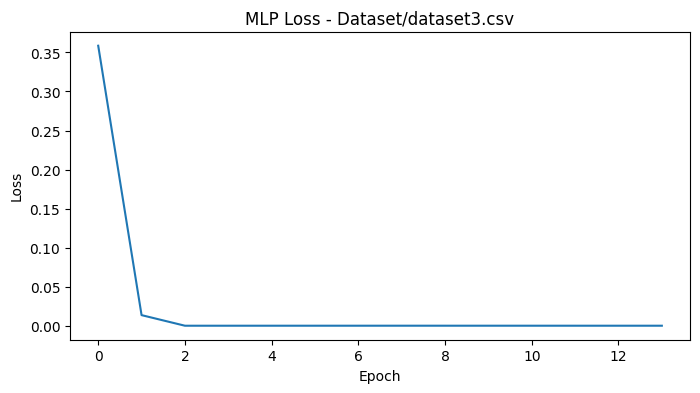

Dataset 3 - Baseline Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 3.8776257038116455}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 4.9372639656066895}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 7.2528064250946045}}

Dataset 3 - PCA Ablation Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.028413772583007812}, 'RandomForest': {'accuracy': 0.9875776397515528, 'precision': 1.0, 'recall': 0.9666666666666667, 'mcc': np.float64(0.9735997330163201), 'time': 0.5057415962219238}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': np.float64(1.0), 'time': 0.12475800514221191}}


In [ ]:
baseline3, ablation3 = process_dataset('Dataset/dataset3.csv')
print("Dataset 3 - Baseline Results:")
print(baseline3)
print("\nDataset 3 - PCA Ablation Results:")
print(ablation3)

### Dataset 4: Wisconsin Diagnostic Breast Cancer
Classic diagnostic dataset with clinical features for distinguishing malignant from benign tumors.

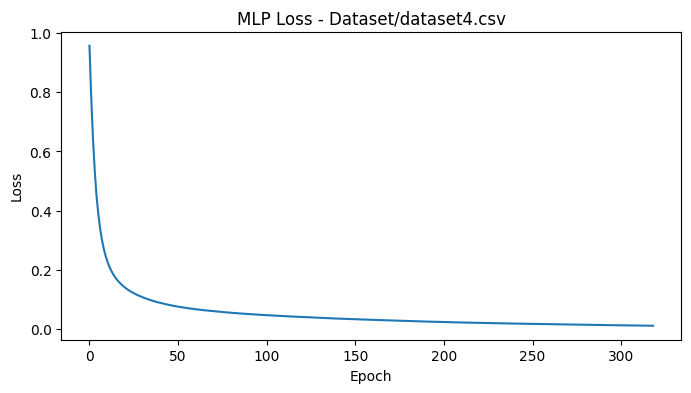

Dataset 4 - Baseline Results:
{'SVC': {'accuracy': 0.9736842105263158, 'precision': 1.0, 'recall': 0.9285714285714286, 'mcc': np.float64(0.9441549509633318), 'time': 0.009250402450561523}, 'RandomForest': {'accuracy': 0.9736842105263158, 'precision': 1.0, 'recall': 0.9285714285714286, 'mcc': np.float64(0.9441549509633318), 'time': 0.29541563987731934}, 'MLP': {'accuracy': 0.9649122807017544, 'precision': 1.0, 'recall': 0.9047619047619048, 'mcc': np.float64(0.9258200997725514), 'time': 3.242464065551758}}

Dataset 4 - PCA Ablation Results:
{'SVC': {'accuracy': 0.9736842105263158, 'precision': 1.0, 'recall': 0.9285714285714286, 'mcc': np.float64(0.9441549509633318), 'time': 0.010259151458740234}, 'RandomForest': {'accuracy': 0.9385964912280702, 'precision': 0.9069767441860465, 'recall': 0.9285714285714286, 'mcc': np.float64(0.868859654660177), 'time': 0.5344753265380859}, 'MLP': {'accuracy': 0.9649122807017544, 'precision': 1.0, 'recall': 0.9047619047619048, 'mcc': np.float64(0.925820099

In [ ]:
baseline4, ablation4 = process_dataset('Dataset/dataset4.csv')
print("Dataset 4 - Baseline Results:")
print(baseline4)
print("\nDataset 4 - PCA Ablation Results:")
print(ablation4)

### Dataset 5: TCGA-LUSC Lung Cancer
Processing the lung squamous cell carcinoma dataset with tumor vs. healthy classification.

/tmp/ipykernel_5703/2575269316.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,221,222,223,224,225,226,227,228,229,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,247,248,249,250,251,252,253,254,255,256,257,258,259,260,261,262,

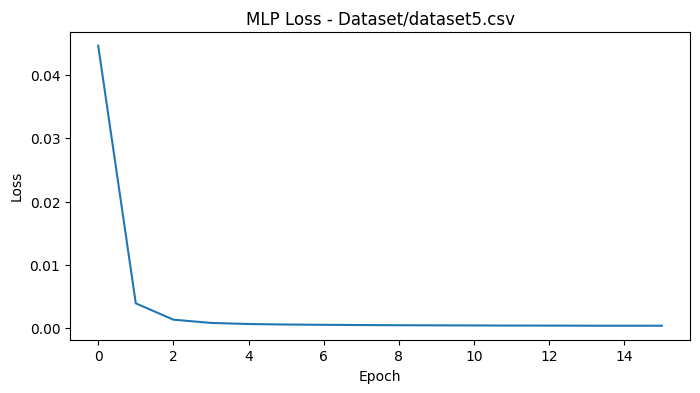

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Dataset 5 - Baseline Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 0.4120597839355469}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 10.20339584350586}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 17.7359778881073}}

Dataset 5 - PCA Ablation Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 0.05678415298461914}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 4.351688385009766}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 7.123821973800659}}


In [ ]:
baseline5, ablation5 = process_dataset('Dataset/dataset5.csv')
print("Dataset 5 - Baseline Results:")
print(baseline5)
print("\nDataset 5 - PCA Ablation Results:")
print(ablation5)

### Dataset 6: Prostate Cancer Genomics
Processing merged GEO prostate cancer dataset classifying normal, benign, and tumor samples.

/tmp/ipykernel_5703/2575269316.py:6: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(csv_path, sep=delimiter)
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning

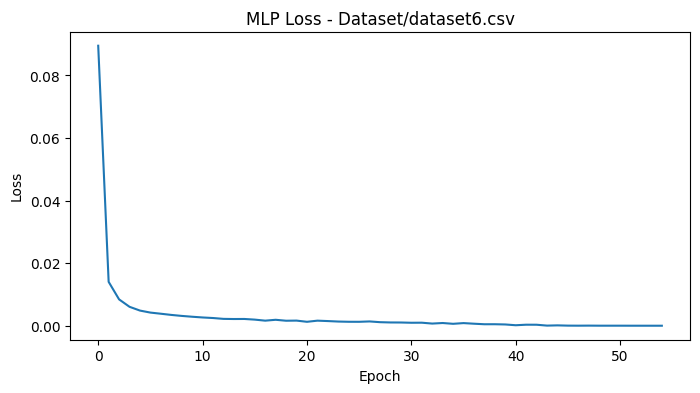

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


Dataset 6 - Baseline Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 0.4255561828613281}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 1.964845895767212}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 10.45194411277771}}

Dataset 6 - PCA Ablation Results:
{'SVC': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 0.2236943244934082}, 'RandomForest': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 1.4497473239898682}, 'MLP': {'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'mcc': 0.0, 'time': 3.047405242919922}}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [ ]:
baseline6, ablation6 = process_dataset('Dataset/dataset6.csv')
print("Dataset 6 - Baseline Results:")
print(baseline6)
print("\nDataset 6 - PCA Ablation Results:")
print(ablation6)

### Dataset 7: Leukemia Gene Expression
Processing curated leukemia microarray dataset with 5 distinct leukemia classes.

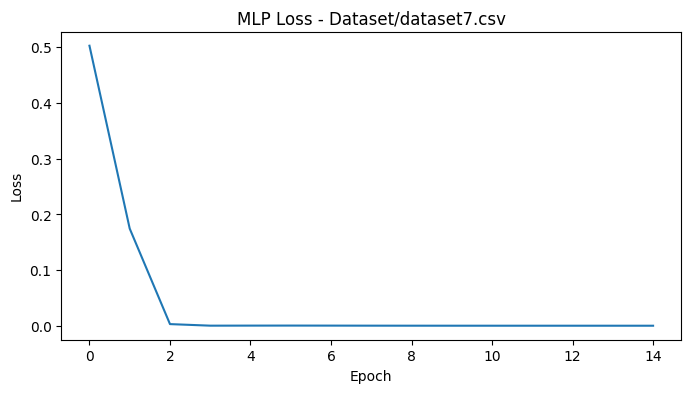

Dataset 7 - Baseline Results:
{'SVC': {'accuracy': 0.9230769230769231, 'precision': 0.9166666666666666, 'recall': 1.0, 'mcc': np.float64(0.67700320038633), 'time': 0.039581298828125}, 'RandomForest': {'accuracy': 0.9230769230769231, 'precision': 0.9166666666666666, 'recall': 1.0, 'mcc': np.float64(0.67700320038633), 'time': 0.2856431007385254}, 'MLP': {'accuracy': 0.7692307692307693, 'precision': 0.9, 'recall': 0.8181818181818182, 'mcc': np.float64(0.27247463045653303), 'time': 1.1924941539764404}}

Dataset 7 - PCA Ablation Results:
{'SVC': {'accuracy': 0.9230769230769231, 'precision': 0.9166666666666666, 'recall': 1.0, 'mcc': np.float64(0.67700320038633), 'time': 0.0024156570434570312}, 'RandomForest': {'accuracy': 0.8461538461538461, 'precision': 0.8461538461538461, 'recall': 1.0, 'mcc': 0.0, 'time': 0.1893784999847412}, 'MLP': {'accuracy': 0.8461538461538461, 'precision': 0.9090909090909091, 'recall': 0.9090909090909091, 'mcc': np.float64(0.4090909090909091), 'time': 0.0233943462371

In [ ]:
baseline7, ablation7 = process_dataset('Dataset/dataset7.csv')
print("Dataset 7 - Baseline Results:")
print(baseline7)
print("\nDataset 7 - PCA Ablation Results:")
print(ablation7)

## Dataset Validation Check
Verify all 7 datasets load correctly and have proper structure before processing.

## Results and Performance Analysis

### Accuracy Comparison Across Datasets
Generate comprehensive tables comparing baseline and PCA-reduced model performance.

In [ ]:
import pandas as pd

all_baselines = []
all_ablations = []
dataset_names = []
available_datasets = []

for i in range(1, 8):
    try:
        baseline = eval(f'baseline{i}')
        ablation = eval(f'ablation{i}')
        all_baselines.append(baseline)
        all_ablations.append(ablation)
        available_datasets.append(i)
    except NameError:
        continue


full_names = [
    'Dataset 1 (CuMiDa BC)', 'Dataset 2 (GSE280902)', 'Dataset 3 (PANCAN)',
    'Dataset 4 (Wisconsin)', 'Dataset 5 (TCGA-LUSC)', 'Dataset 6 (Prostate)',
    'Dataset 7 (Leukemia)'
]

dataset_names = [full_names[i-1] for i in available_datasets]

print("Results for all processed datasets:")
print("=" * 60)

for i, (ds_name, base, abl) in enumerate(zip(dataset_names, all_baselines, all_ablations)):
    print(f"\n{ds_name}")
    print("-" * 40)

    for model in ['SVC', 'RandomForest', 'MLP']:
        base_acc = base[model]['accuracy']
        abl_acc = abl[model]['accuracy']
        base_time = base[model]['time']
        abl_time = abl[model]['time']
        speedup = base_time / abl_time if abl_time > 0 else 0

        print(f"{model:12} | Base: {base_acc:.3f} | PCA: {abl_acc:.3f} | Speed: {speedup:.1f}x")

print("\n" + "=" * 60)
print("Average Performance Across All Datasets")
print("=" * 60)

avg_svc_base = np.mean([b['SVC']['accuracy'] for b in all_baselines])
avg_rf_base = np.mean([b['RandomForest']['accuracy'] for b in all_baselines])
avg_mlp_base = np.mean([b['MLP']['accuracy'] for b in all_baselines])

avg_svc_abl = np.mean([a['SVC']['accuracy'] for a in all_ablations])
avg_rf_abl = np.mean([a['RandomForest']['accuracy'] for a in all_ablations])
avg_mlp_abl = np.mean([a['MLP']['accuracy'] for a in all_ablations])

print(f"SVC          | Base: {avg_svc_base:.3f} | PCA: {avg_svc_abl:.3f}")
print(f"Random Forest| Base: {avg_rf_base:.3f} | PCA: {avg_rf_abl:.3f}")
print(f"MLP          | Base: {avg_mlp_base:.3f} | PCA: {avg_mlp_abl:.3f}")

best_acc = max(avg_svc_base, avg_rf_base, avg_mlp_base)
best_model = ['SVC', 'Random Forest', 'MLP'][[avg_svc_base, avg_rf_base, avg_mlp_base].index(best_acc)]

print(f"\nBest model: {best_model} with {best_acc:.3f} average accuracy")

Results for all processed datasets:

Dataset 1 (CuMiDa BC)
----------------------------------------
SVC          | Base: 1.000 | PCA: 1.000 | Speed: 141.2x
RandomForest | Base: 1.000 | PCA: 1.000 | Speed: 2.8x
MLP          | Base: 0.903 | PCA: 0.968 | Speed: 298.3x

Dataset 2 (GSE280902)
----------------------------------------
SVC          | Base: 0.727 | PCA: 0.727 | Speed: 10.3x
RandomForest | Base: 0.727 | PCA: 0.636 | Speed: 1.8x
MLP          | Base: 0.545 | PCA: 0.818 | Speed: 73.3x

Dataset 3 (PANCAN)
----------------------------------------
SVC          | Base: 1.000 | PCA: 1.000 | Speed: 136.5x
RandomForest | Base: 1.000 | PCA: 0.988 | Speed: 9.8x
MLP          | Base: 1.000 | PCA: 1.000 | Speed: 58.1x

Dataset 4 (Wisconsin)
----------------------------------------
SVC          | Base: 0.974 | PCA: 0.974 | Speed: 0.9x
RandomForest | Base: 0.974 | PCA: 0.939 | Speed: 0.6x
MLP          | Base: 0.965 | PCA: 0.965 | Speed: 3.7x

Dataset 5 (TCGA-LUSC)
-------------------------------